IRIS FLOWER CLASSIFICATION

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

Load Dataset

In [2]:
df = pd.read_csv("IRIS.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Data Cleaning

In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

print("\nFinal Shape:", df.shape)

df.info()

Missing Values:

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate Rows: 3

Final Shape: (147, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.9+ KB


Visualization

Species Count

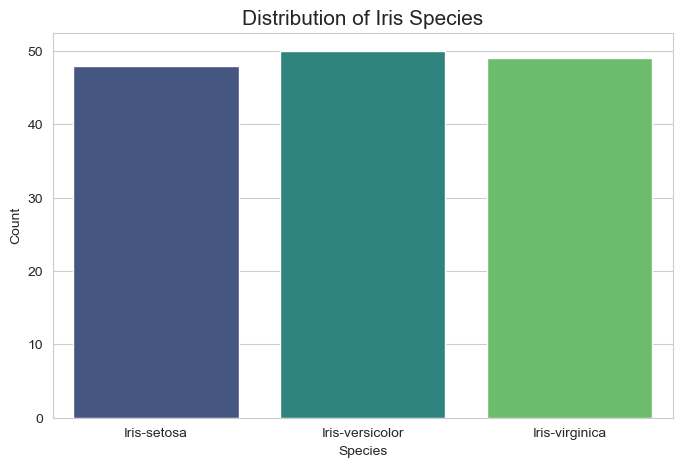

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='species',
    hue='species',
    palette='viridis',
    legend=False
)

plt.title("Distribution of Iris Species", fontsize=15)
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

Pairplot

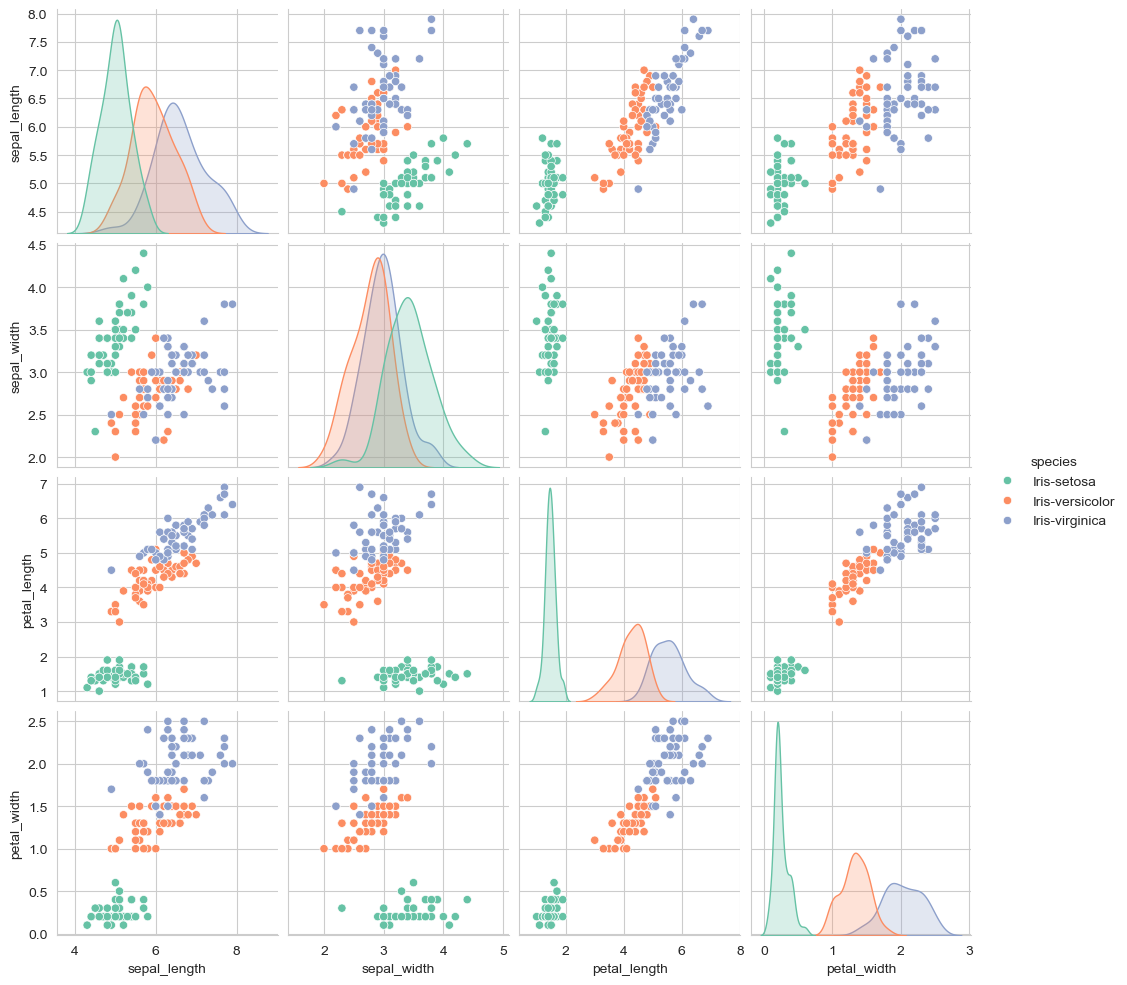

In [5]:
sns.pairplot(
    df,
    hue='species',
    palette='Set2'
)

plt.show()

Correlation Heatmap

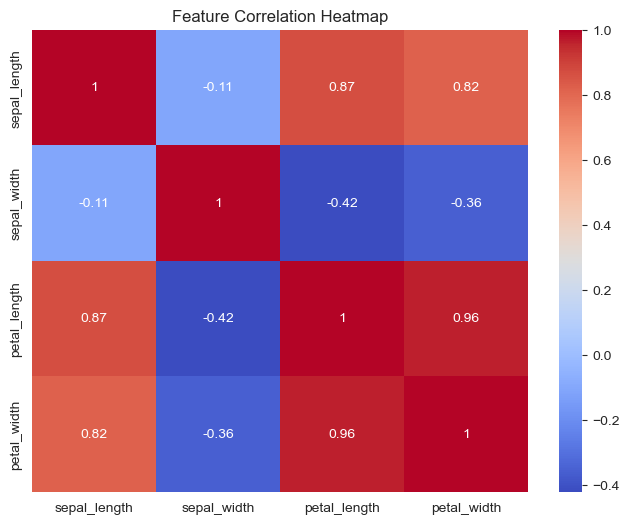

In [6]:
plt.figure(figsize=(8,6))

numeric_df = df.drop('species', axis=1)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

Label Encoding

In [7]:
le = LabelEncoder()

df['species'] = le.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Features and Target

In [8]:
X = df.drop('species', axis=1)

y = df['species']

print(X.shape)
print(y.shape)

(147, 4)
(147,)


Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [10]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


Prediction

In [11]:
y_pred = model.predict(X_test)
print("Prediction Completed")

Prediction Completed


Accuracy

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", round(accuracy*100,2), "%")

Accuracy Score: 93.33 %


Confusion Matrix

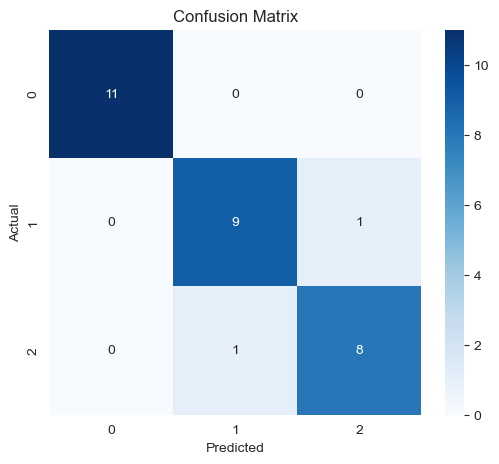

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [14]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Feature Importance

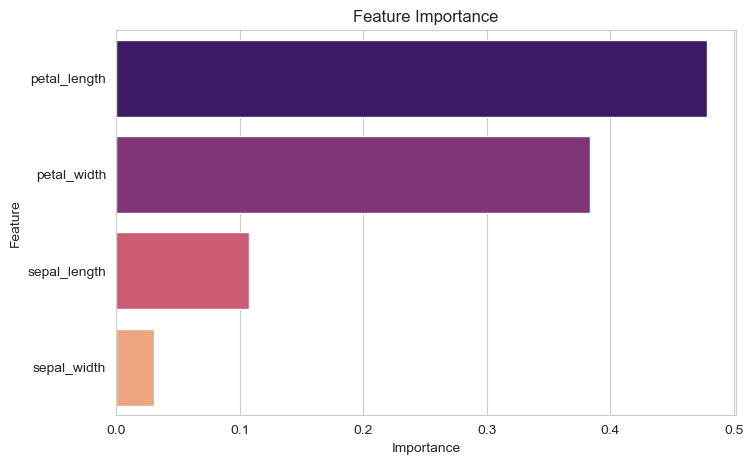

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='magma',
    legend=False
)

plt.title("Feature Importance")

plt.show()